## Problem Statement
> Create a model that will be able to predict if a patient has diabetes or not

## Dataset
The dataset used is the Pima Indian Diabetes Database from Kaggle. The link is https://www.kaggle.com/datasets/mragpavank/diabetes

## Evaluation
> Primary evaluation metric: Recall. The goal is to minimize false negatives because failing to identify a patient who may have diabetes is considered more costly than generating a false positive. A target recall of 90% will be investigated, while also monitoring precision and other relevant metrics.

## Features
1. Pregnancies: Number of times pregnant.
2. Glucose: Plasma glucose concentration from a oral glucose tolerance test.
3. Blood Pressure: Diastolic blood pressure (mm Hg).
4. Skin Thickness: Triceps skin fold thickness (mm).
5. Insulin: 2-Hour serum insulin (μU/ml).BMI: Body mass index (weight in kg/(height in m)²).
6. Diabetes Pedigree Function: Score providing information on diabetes history in relatives.
7. Age: Age in years.
8. Outcome (0 for non-diabetic, 1 for diabetic)

## Load Dataset

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
# Check the shape of the data
df.shape

(768, 9)

There are 768 patients in the dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


There are no missing values 

In [7]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

There are no duplicates

In [8]:
# Let's look at statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Some zero values are likely representing missing measurements rather than genuine physiological measurements. The zero values in the `Glucose`, `Blood Pressure`, `Skin Thickness`, `Insulin` and `BMI` columns will be treated as missing values.

In [32]:
# View the total number of 0 values in each column
(df==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [40]:
# View the average percentage of 0 values in each column
(df == 0).mean() * 100

Pregnancies                 14.453125
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                     65.104167
dtype: float64

Almost half of the data has 0 `Insulin` value

In [38]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    print((df.groupby('Outcome')[col].apply(lambda x: (x == 0).sum())))

Outcome
0    3
1    2
Name: Glucose, dtype: int64
Outcome
0    19
1    16
Name: BloodPressure, dtype: int64
Outcome
0    139
1     88
Name: SkinThickness, dtype: int64
Outcome
0    236
1    138
Name: Insulin, dtype: int64
Outcome
0    9
1    2
Name: BMI, dtype: int64


The 0 `Insulin` values are more in non-diabetes (Outcome 0) by a 100 in diabetes in (Outcome 1)

## Exploratory Data Analysis

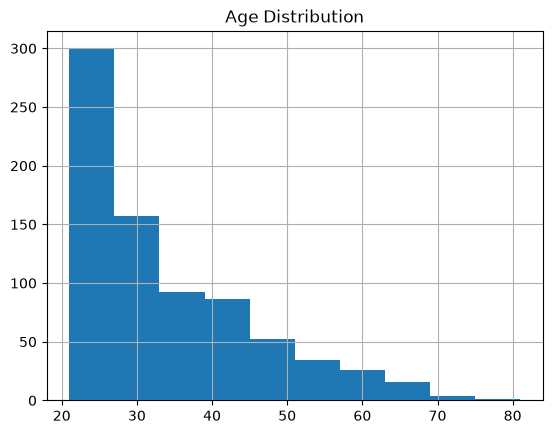

In [11]:
# Age Distribution
df['Age'].hist()
plt.title('Age Distribution');

The age distribution is positively skewed, with most patients concentrated in the younger age groups, particularly between approximately 21 and 30 years. The frequency of patients decreases as age increases, resulting in a long right tail extending to approximately 80 years. This indicates that the dataset contains substantially more younger patients than older patients.

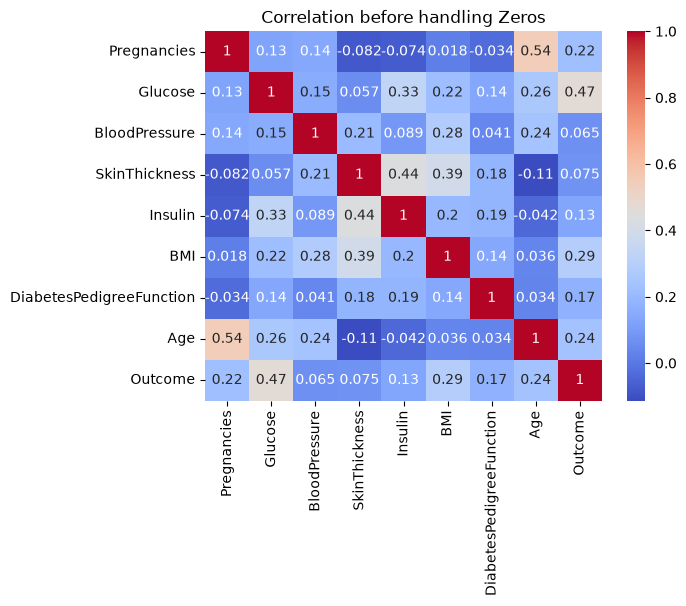

In [42]:
# Let's Check for correlation
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation before handling Zeros');

* There is a moderate positive correlation between `Age` and `Pregnancies`. 
* The `Outcome` is also moderately correlated with `Glucose` postively.
* The is a moderate positive correlation between `SkinThickness` and `Insulin`.
* The is a moderate positive correlation between `SkinThickness` and `BMI`.

In [43]:
data2 = df.copy()

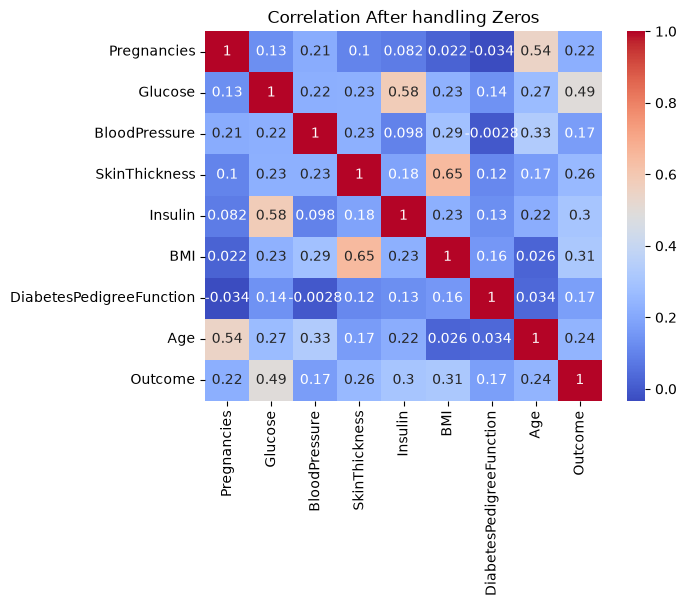

In [45]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    data2[col] = data2[col].replace(0, np.nan)
correlation = data2.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation After handling Zeros');

* `Insulin` now has a high correlation with `Glucose`
* The correlation between `SkinThickness` and `BMI` is much higher now

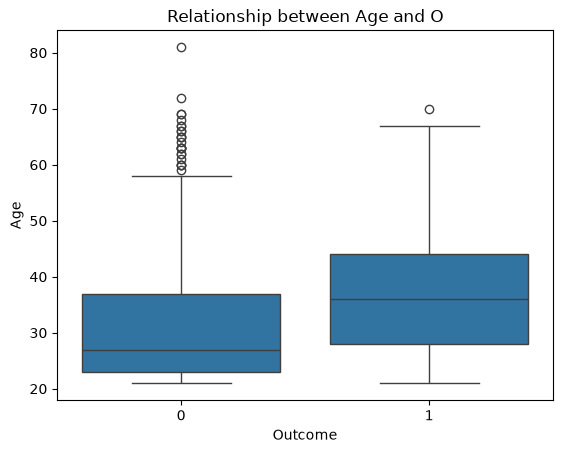

In [46]:
# Let's look at the relationship between Age and Outcome
sns.boxplot(x=df.Outcome, y=df.Age)
plt.title('Relationship between Age and O');

* 50% of patients with diabetes (Outcome 1) fall between the ages of approximately 29 to 44, with a median of approximately 37. There is an outlier that is 70
* 50% of patients without diabetes (Outcome 2) fall between the ages of approximately 23 to 38, with a median of approximately 28. Though there are several old age outliers, they may represent legitimate observations rather than errors.
* Therefore patients with diabetes tend to be older than patients without diabetes.
* Overall, the dustribution suggests that age may be associated with diabetes status, although there is substantial overlap between the two groups.

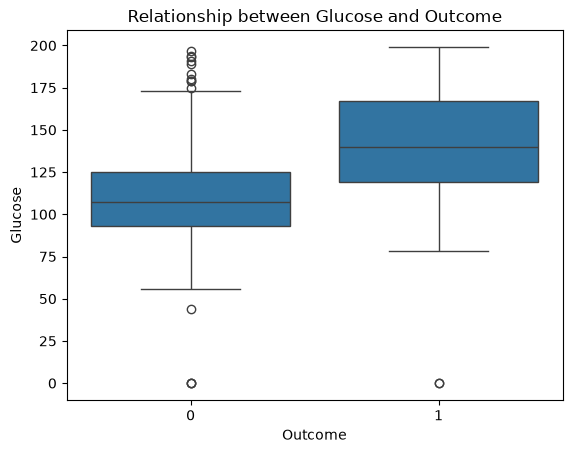

In [26]:
# Let's look at the relationship between Glucose and Outcome
sns.boxplot(x=df.Outcome, y=df.Glucose)
plt.title('Relationship between Glucose and Outcome');

Patients with diabetes (Outcome 1) tend to have a much higher glucose level of approximately 140 when compared to 110 of non-diabetes (Outcome 0). 
50% of patients with diabetes fall within the range of approximately 120 to 170 while for non-diabetes it is approximately 90 to 125.
There are some outliers in the non-diabetes plot that overlap with the maximum boundary of the diabetes plot. The clear difference in glucose distributions suggest that glucose level may be associated with diabetes status.

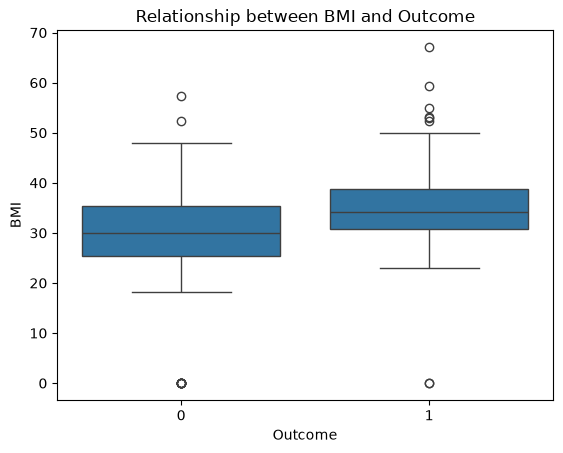

In [27]:
# Let's look at the relationship between BMI and Outcome
sns.boxplot(x=df.Outcome, y=df.BMI)
plt.title('Relationship between BMI and Outcome');

Patients with diabetes (Outcome 1) tend to have a higher BMI of approximately 35 than those without diabetes (Outcome 0) with approximately 30. There are outliers of high BMI which might suggest abnormal BMI. The 0 values are physiologically implausible and will be addressed as missing values.
The difference in BMI distributions suggests that BMI may be associated with diabetes status.